# Edge-weighted Graph Decomposition


In [ ]:
import os
from pathlib import Path

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
from itertools import combinations

from TopNMF import (
    TopologicalNMF,
    GraphFiltrationPH,
    clique_deviation_loss,
    generate_edge_weighted_graph,
    plot_gallery_graph,
)
from TopNMF.visualization import FitMonitor
from sklearn.decomposition import NMF

device = "cpu"


## Synthetic data
Decompose a synthetic edge-weighted graph with overlapping cliques using **Top-NMF** with a graph filtration persistence complex, and compare against standard NMF.

X shape: (3, 36), edges: 36


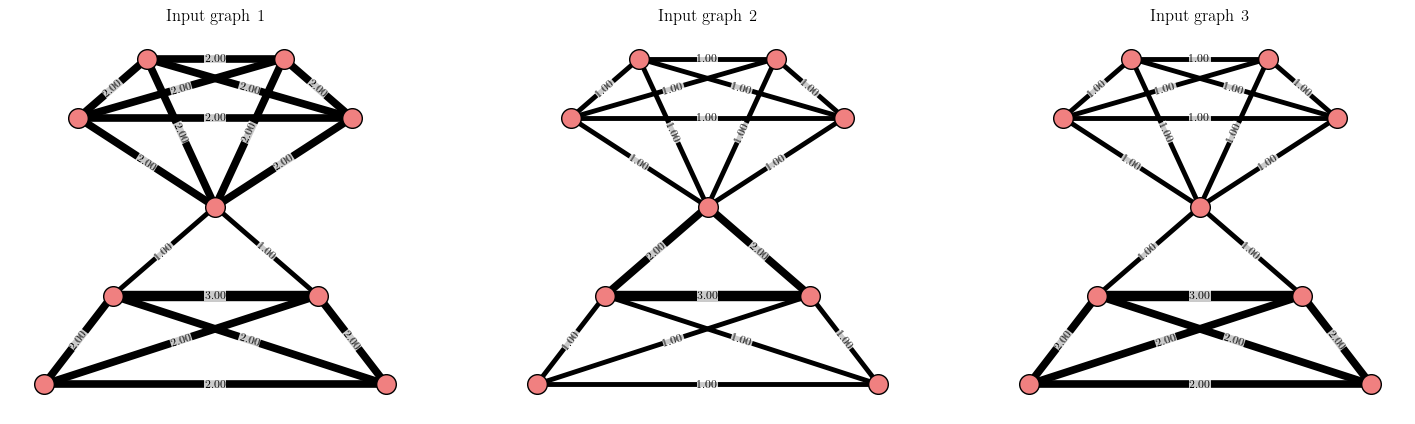

In [4]:
X, all_edges = generate_edge_weighted_graph()
print(f"X shape: {X.shape}, edges: {len(all_edges)}")
fixed_pos = {
    5: (0, 0),
    4: (-2, 1.5), 3: (-1, 2.5), 2: (1, 2.5), 1: (2, 1.5),
    6: (-1.5, -1.5), 7: (1.5, -1.5), 8: (-2.5, -3.0), 9: (2.5, -3.0),
}

_=plot_gallery_graph(X, torch.tensor(all_edges).T, title="Input graph", pos=fixed_pos)

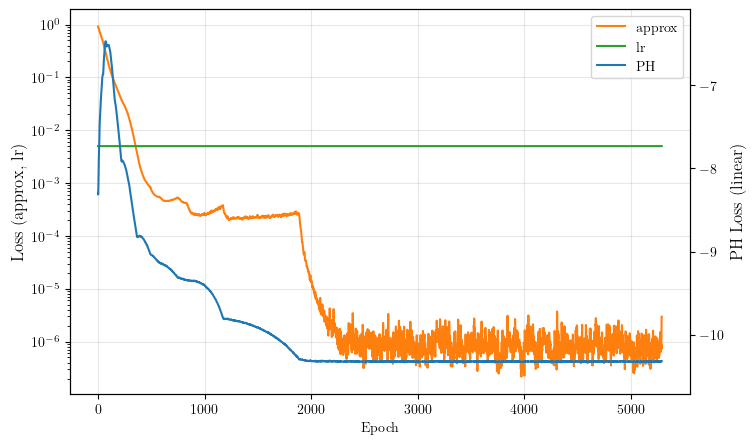

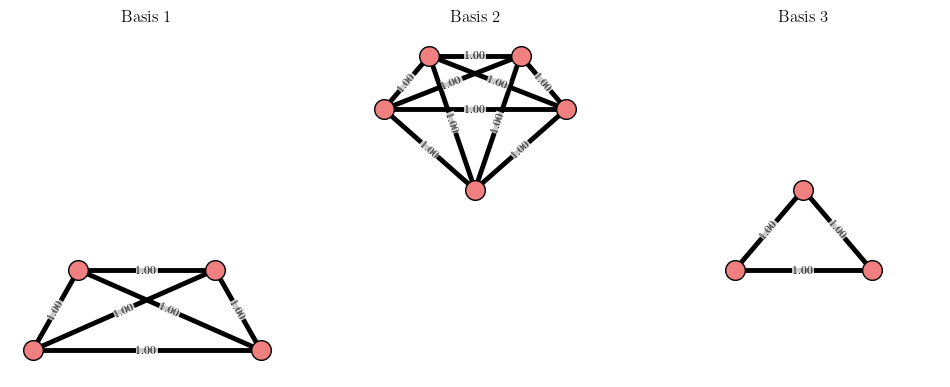

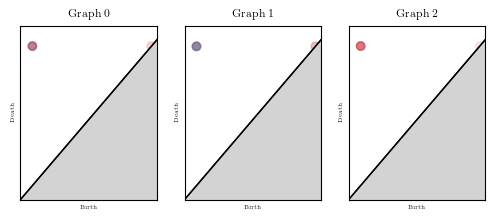

  0%|          | 0/5300 [00:00<?, ?it/s]

In [ ]:
n_components = 3

# Superlevel graph filtration tracking H0 and H1
ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)

# Empty target diagrams encourage topologically simple bases
target_diagrams = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=43,
    complex=ph_complex,
    use_embedding=False,
    ph_loss_fn=clique_deviation_loss,
    ph_loss_params={"alpha": 1.0, "remove_longest": {0: False, 1: False}},
)

monitor = FitMonitor(
    show=["loss", "PH", "basis"],
    interval=10,
    factor=1.0,
    grid=(1, 3),
    superlevel=True,
    save_video=True,
    plot_size=2.0,
)

model.fit(
    X,
    n_iterations=3000,
    lr=0.005,
    lambda_top=0.01,
    PH_dims=[0, 1],
    complex_inputs={"all_edges": all_edges, "node_pos": fixed_pos},
    verbose=True,
    target_diagrams=target_diagrams,
    normalize_V_max=True,
    init_method="random",
    monitor=monitor,
)

plt.close("all")

In [7]:
monitor.save("graph.mp4", show=["basis"], fps=10)
monitor.save("graph_ph.mp4", show=["PH"], fps=10)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 451) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 225) to (608, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: graph.mp4
Video saved: graph_ph.mp4


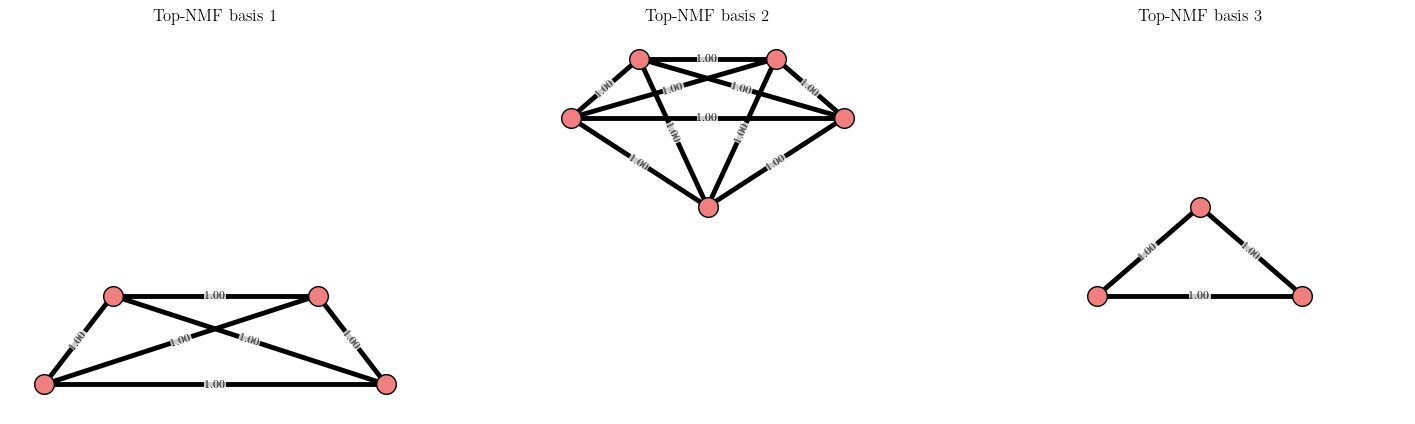

In [6]:
# Top-NMF basis vectors
_=plot_gallery_graph(
    model.V.detach().cpu().numpy(),
    torch.tensor(all_edges).T,
    title="Top-NMF basis",
    pos=fixed_pos,
)

## Compare with standard NMF

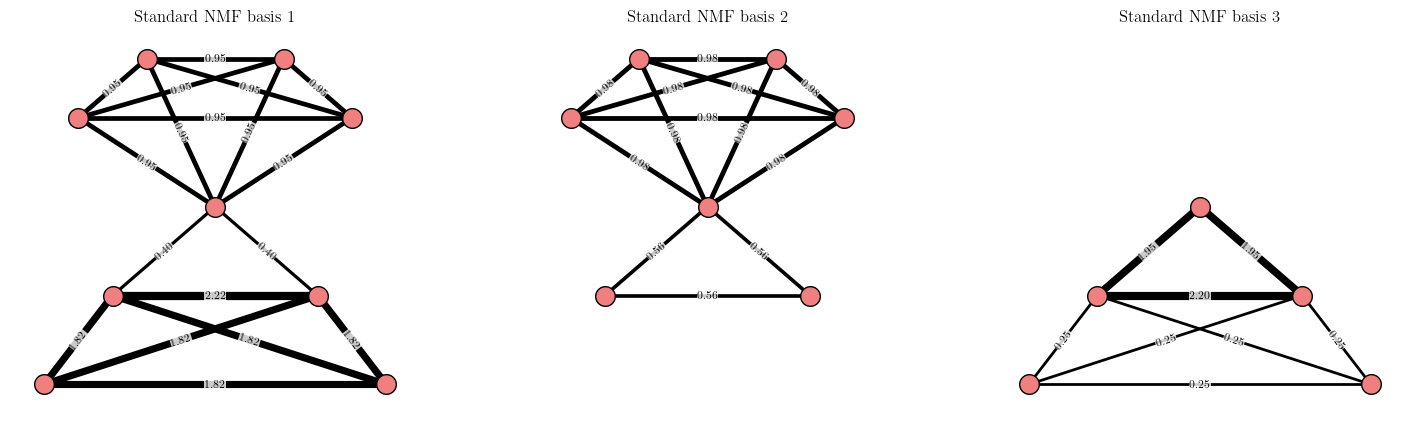

In [ ]:
# Standard NMF on the same edge-weight matrix
nmf = NMF(n_components=n_components, init="random", random_state=43)
W_std = nmf.fit_transform(X)
H_std = nmf.components_

# Standard NMF basis vectors
_=plot_gallery_graph(
    H_std,
    torch.tensor(all_edges).T,
    title="Standard NMF basis",
    pos=fixed_pos,
)

In [ ]:
def cp_alpha_component_scores(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    alpha: float = 1.0,
) -> List[float]:
    """
    Compute the positive CP_alpha score used by ``clique_deviation_loss``.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over graph nodes.
    alpha : float, optional
        Weight for higher-dimensional persistence terms.

    Returns
    -------
    list of float
        Per-component CP_alpha scores; larger values indicate stronger clique-like topology.
    """
    ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)
    target_diagrams = [
        torch.zeros((0, 2), dtype=torch.float32, device=device),
        torch.zeros((0, 2), dtype=torch.float32, device=device),
    ]
    scores = []
    for component in components:
        component_t = torch.as_tensor(component, dtype=torch.float32, device=device)
        diagrams = ph_complex(edges, component_t)
        loss = clique_deviation_loss(
            diagrams,
            [0, 1],
            target_diagrams,
            device,
            alpha=alpha,
            remove_longest={0: False, 1: False},
        )
        scores.append(float((-loss).detach().cpu().item()))
    return scores


def plot_cp_alpha_score_comparison(
    top_scores: List[float],
    standard_scores: List[float],
    title: str,
) -> Tuple[Figure, np.ndarray]:
    """
    Compare CP_alpha component scores between Top-NMF and standard NMF.

    Parameters
    ----------
    top_scores : list of float
        Top-NMF CP_alpha scores.
    standard_scores : list of float
        Standard NMF CP_alpha scores.
    title : str
        Figure title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    x = np.arange(len(top_scores))
    width = 0.36
    fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
    ax.bar(x - width / 2, top_scores, width, label="Top-NMF", color="#3b7ddd")
    ax.bar(x + width / 2, standard_scores, width, label="Standard NMF", color="#9aa5b1")
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{i + 1}" for i in x])
    ax.set_ylabel("CP_alpha score")
    ax.set_title(title)
    ax.legend(frameon=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_cp_alpha_report(
    dataset_name: str,
    top_scores: List[float],
    standard_scores: List[float],
) -> None:
    """
    Print a compact CP_alpha comparison report.

    Parameters
    ----------
    dataset_name : str
        Dataset name for display.
    top_scores : list of float
        Top-NMF CP_alpha scores.
    standard_scores : list of float
        Standard NMF CP_alpha scores.

    Returns
    -------
    None
    """
    top_mean = float(np.mean(top_scores))
    standard_mean = float(np.mean(standard_scores))
    print(
        f"{dataset_name} CP_alpha: Top-NMF mean={top_mean:.3f}, "
        f"standard NMF mean={standard_mean:.3f}, advantage={top_mean - standard_mean:.3f}"
    )


def plot_separation_comparison(
    top_stats: Dict[str, np.ndarray],
    standard_stats: Dict[str, np.ndarray],
) -> Tuple[Figure, np.ndarray]:
    """
    Compare the strongest ictal component separation for both methods.

    Parameters
    ----------
    top_stats : dict of str to np.ndarray
        Top-NMF state statistics.
    standard_stats : dict of str to np.ndarray
        Standard NMF state statistics.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    values = [float(np.max(top_stats["cohen_d"])), float(np.max(standard_stats["cohen_d"]))]
    fig, ax = plt.subplots(figsize=(4.8, 3.2), constrained_layout=True)
    ax.bar([0, 1], values, color=["#3b7ddd", "#9aa5b1"], width=0.58)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Top-NMF", "Standard NMF"])
    ax.set_ylabel("Best ictal Cohen's d")
    ax.set_title("Ictal-component separation")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_state_separation_report(
    top_stats: Dict[str, np.ndarray],
    standard_stats: Dict[str, np.ndarray],
) -> None:
    """
    Print a compact Top-NMF versus standard NMF state-separation report.

    Parameters
    ----------
    top_stats : dict of str to np.ndarray
        Top-NMF state statistics.
    standard_stats : dict of str to np.ndarray
        Standard NMF state statistics.

    Returns
    -------
    None
    """
    rows = [("Top-NMF", top_stats), ("Standard NMF", standard_stats)]
    for name, stats in rows:
        best = int(np.argmax(stats["cohen_d"]))
        print(
            f"{name}: best ictal component C{best + 1}, "
            f"delta={stats['delta'][best]:.3f}, Cohen's d={stats['cohen_d'][best]:.3f}"
        )
    advantage = float(np.max(top_stats["cohen_d"]) - np.max(standard_stats["cohen_d"]))
    if advantage >= 0:
        print(f"Top-NMF state-separation advantage over standard NMF: {advantage:.3f} Cohen's d")
    else:
        print(f"State-separation difference (Top-NMF - standard NMF): {advantage:.3f} Cohen's d")

## SocioPatterns high-school contact network experiment

This section uses the SocioPatterns High School Dynamic Contact Networks datasets (**2011** and **2012** deployments) as direct clique-recovery examples for `CP_alpha`. Each deployment contains face-to-face contact records at 20-second resolution. We build sliding-window contact-duration graphs and run Top-NMF to recover within-class contact structures, comparing against standard NMF using the class-module score (within-class top-edge mass).

Both years are processed with the same pipeline so results are directly comparable. Sources: [SocioPatterns High School 2011](https://sociopatterns.org/datasets/high-school-contact-and-friendship-networks/) and [2012](https://sociopatterns.org/datasets/high-school-2012-data-set/).

In [ ]:
import gzip
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from urllib.request import urlretrieve
from matplotlib.figure import Figure

SOCIOPATTERNS_CACHE_DIR = Path("data/sociopatterns")

SOCIOPATTERNS_DATASETS = {
    "2011": {
        "contact_url": "https://sociopatterns.org/assets/data/highschool_2011.csv.gz",
        "metadata_url": "https://sociopatterns.org/assets/data/highschool_2011_metadata.txt",
        "contact_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2011.csv.gz",
        "metadata_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2011_metadata.txt",
    },
    "2012": {
        "contact_url": "https://sociopatterns.org/assets/data/highschool_2012.csv.gz",
        "metadata_url": "https://sociopatterns.org/assets/data/highschool_2012_metadata.txt",
        "contact_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2012.csv.gz",
        "metadata_path": SOCIOPATTERNS_CACHE_DIR / "highschool_2012_metadata.txt",
    },
}


def download_sociopatterns_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not output_path.exists():
        print(f"Downloading {url} -> {output_path}")
        urlretrieve(url, output_path)
    return output_path


def load_highschool_metadata(path: Path) -> Dict[int, Dict[str, str]]:
    tokens = path.read_text().split()
    metadata = {}
    for idx in range(0, len(tokens), 3):
        person_id = int(tokens[idx])
        metadata[person_id] = {"class": tokens[idx + 1], "gender": tokens[idx + 2]}
    return metadata


def load_highschool_contacts(path: Path) -> List[Tuple[int, int, int, str, str]]:
    rows = []
    with gzip.open(path, "rt") as handle:
        for line in handle:
            parts = line.split()
            if len(parts) < 5:
                continue
            rows.append((int(parts[0]), int(parts[1]), int(parts[2]), parts[3], parts[4]))
    return rows


def select_active_students_by_class(
    contacts: List[Tuple[int, int, int, str, str]],
    metadata: Dict[int, Dict[str, str]],
    per_class: int = 8,
) -> List[int]:
    activity = Counter()
    for _, left, right, _, _ in contacts:
        activity[left] += 1
        activity[right] += 1

    by_class = defaultdict(list)
    for person_id, info in metadata.items():
        class_name = info["class"]
        if class_name.lower() == "teacher":
            continue
        by_class[class_name].append(person_id)

    selected = []
    for class_name in sorted(by_class):
        ranked = sorted(by_class[class_name], key=lambda node: (-activity[node], node))
        selected.extend(ranked[:per_class])
    return selected


RUN_SOCIOPATTERNS_EXPERIMENT = True

sp_data = {}  # year -> dict with loaded data and "ready" flag

if RUN_SOCIOPATTERNS_EXPERIMENT:
    for year, cfg in SOCIOPATTERNS_DATASETS.items():
        try:
            contact_path = download_sociopatterns_file(cfg["contact_url"], cfg["contact_path"])
            metadata_path = download_sociopatterns_file(cfg["metadata_url"], cfg["metadata_path"])
            metadata = load_highschool_metadata(metadata_path)
            contacts = load_highschool_contacts(contact_path)
            selected_ids = select_active_students_by_class(contacts, metadata, per_class=8)
            node_classes = [metadata[node_id]["class"] for node_id in selected_ids]
            edges = list(combinations(range(len(selected_ids)), 2))
            sp_data[year] = {
                "contacts": contacts,
                "metadata": metadata,
                "selected_ids": selected_ids,
                "node_classes": node_classes,
                "edges": edges,
                "ready": True,
            }
            print(
                f"SocioPatterns {year}: {len(selected_ids)} nodes, "
                f"{len(edges)} edges, classes={sorted(set(node_classes))}"
            )
        except Exception as exc:
            print(f"Skipping SocioPatterns {year}: {exc}")
            sp_data[year] = {"ready": False}
else:
    print("Set RUN_SOCIOPATTERNS_EXPERIMENT = True to run the SocioPatterns experiments.")

SOCIOPATTERNS_READY = any(v["ready"] for v in sp_data.values())

In [ ]:
def build_sociopatterns_contact_matrix(
    contacts: List[Tuple[int, int, int, str, str]],
    selected_ids: List[int],
    window_seconds: int = 1800,
    step_seconds: int = 900,
    contact_interval_seconds: int = 20,
    min_window_contacts: int = 4,
) -> Tuple[np.ndarray, List[Tuple[int, int]], List[Tuple[int, int]]]:
    """
    Build sliding-window contact-duration graphs.

    Parameters
    ----------
    contacts : list of tuple
        Temporal contact rows ``(t, i, j, class_i, class_j)``.
    selected_ids : list of int
        Person IDs retained as graph nodes.
    window_seconds : int, optional
        Aggregation window length.
    step_seconds : int, optional
        Sliding-window step.
    contact_interval_seconds : int, optional
        Duration represented by one active-contact row.
    min_window_contacts : int, optional
        Minimum selected-subgraph contacts required to keep a window.

    Returns
    -------
    X : np.ndarray
        Window-by-edge non-negative duration matrix.
    edges : list of tuple of int
        Complete graph edge list over selected nodes.
    bounds : list of tuple of int
        Kept window bounds in seconds.
    """
    node_lookup = {node_id: idx for idx, node_id in enumerate(selected_ids)}
    edges = list(combinations(range(len(selected_ids)), 2))
    edge_lookup = {tuple(sorted(edge)): idx for idx, edge in enumerate(edges)}
    selected_set = set(selected_ids)
    selected_contacts = [
        (time, left, right)
        for time, left, right, _, _ in contacts
        if left in selected_set and right in selected_set
    ]
    if not selected_contacts:
        raise ValueError("No contacts remain after selecting the SocioPatterns node subset.")

    times = np.asarray([time for time, _, _ in selected_contacts], dtype=int)
    start = int(times.min())
    stop = int(times.max())
    rows = []
    bounds = []
    for t0 in range(start, stop - window_seconds + step_seconds, step_seconds):
        t1 = t0 + window_seconds
        row = np.zeros(len(edges), dtype=float)
        contact_count = 0
        for time, left, right in selected_contacts:
            if t0 < time <= t1:
                u = node_lookup[left]
                v = node_lookup[right]
                row[edge_lookup[tuple(sorted((u, v)))]] += contact_interval_seconds
                contact_count += 1
        if contact_count >= min_window_contacts:
            rows.append(row)
            bounds.append((t0, t1))

    X = np.vstack(rows)
    X /= np.maximum(X.max(axis=1, keepdims=True), 1e-12)
    return X, edges, bounds


def class_block_layout(node_classes: List[str]) -> Dict[int, Tuple[float, float]]:
    """
    Place nodes in class-specific circular blocks.

    Parameters
    ----------
    node_classes : list of str
        Class label for each node.

    Returns
    -------
    dict of int to tuple of float
        Node positions for network plotting.
    """
    classes = sorted(set(node_classes))
    angles = np.linspace(0, 2 * np.pi, len(classes), endpoint=False)
    centers = {
        class_name: np.array([2.8 * np.cos(angle), 2.8 * np.sin(angle)])
        for class_name, angle in zip(classes, angles)
    }
    pos = {}
    for class_name in classes:
        nodes = [idx for idx, label in enumerate(node_classes) if label == class_name]
        local_angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
        for node_idx, angle in zip(nodes, local_angles):
            offset = np.array([0.85 * np.cos(angle), 0.85 * np.sin(angle)])
            pos[node_idx] = tuple(centers[class_name] + offset)
    return pos

In [ ]:
sp_models = {}  # year -> {"top_model": ..., "H_std": ...}

for year, data in sp_data.items():
    if not data["ready"]:
        print(f"SocioPatterns {year} fit skipped.")
        continue

    X_sp, sp_edges, sp_window_bounds = build_sociopatterns_contact_matrix(
        contacts=data["contacts"],
        selected_ids=data["selected_ids"],
        window_seconds=1800,
        step_seconds=900,
        min_window_contacts=4,
    )
    sp_pos = class_block_layout(data["node_classes"])
    print(f"SocioPatterns {year}: X shape {X_sp.shape}, kept windows: {len(sp_window_bounds)}")
    data["X"] = X_sp
    data["sp_edges"] = sp_edges
    data["sp_pos"] = sp_pos

    n_components_sp = len(sorted(set(data["node_classes"])))
    target_diagrams_sp = [
        torch.zeros((0, 2), dtype=torch.float32, device=device),
        torch.zeros((0, 2), dtype=torch.float32, device=device),
    ]

    sp_model = TopologicalNMF(
        n_components=n_components_sp,
        device=device,
        random_state=23,
        complex=GraphFiltrationPH(max_dim=1, superlevel=True),
        use_embedding=False,
        ph_loss_fn=clique_deviation_loss,
        ph_loss_params={"alpha": 1.0, "remove_longest": {0: False, 1: False}},
    )
    sp_model.fit(
        X_sp,
        n_iterations=1000,
        lr=0.005,
        lambda_top=0.01,
        lambda_apx=1.0,
        PH_dims=[0, 1],
        complex_inputs={"all_edges": sp_edges, "node_pos": sp_pos},
        verbose=True,
        target_diagrams=target_diagrams_sp,
        normalize_V_max=True,
        init_method="nndsvda",
        scheduler_cls=None,
    )

    nmf_sp = NMF(
        n_components=n_components_sp,
        init="nndsvda",
        random_state=23,
        max_iter=5000,
        tol=1e-5,
    )
    W_sp_std = nmf_sp.fit_transform(X_sp)
    H_sp_std = nmf_sp.components_

    sp_models[year] = {"top_model": sp_model, "H_std": H_sp_std}

if not sp_models:
    print("No SocioPatterns fits completed.")

In [ ]:
def component_class_module_scores(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    node_classes: List[str],
    threshold_quantile: float = 0.85,
) -> List[Dict[str, object]]:
    """
    Score how strongly each component concentrates on within-class edges.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over node indices.
    node_classes : list of str
        Class label for each node.
    threshold_quantile : float, optional
        Quantile defining top edges used for the score.

    Returns
    -------
    list of dict
        Per-component within-class and dominant-class scores.
    """
    scores = []
    for component in components:
        positive = component[component > 0]
        threshold = np.quantile(positive, threshold_quantile) if positive.size else np.inf
        total_weight = 0.0
        within_weight = 0.0
        class_weight = defaultdict(float)
        for edge_idx, (u, v) in enumerate(edges):
            weight = float(component[edge_idx])
            if weight < threshold:
                continue
            total_weight += weight
            if node_classes[u] == node_classes[v]:
                within_weight += weight
                class_weight[node_classes[u]] += weight
        dominant_class = max(class_weight, key=class_weight.get) if class_weight else "none"
        dominant_weight = float(class_weight[dominant_class]) if class_weight else 0.0
        scores.append({
            "within_ratio": within_weight / max(total_weight, 1e-12),
            "dominant_class": dominant_class,
            "dominant_ratio": dominant_weight / max(total_weight, 1e-12),
        })
    return scores


def plot_sociopatterns_components(
    components: np.ndarray,
    edges: List[Tuple[int, int]],
    node_classes: List[str],
    pos: Dict[int, Tuple[float, float]],
    title: str,
    scores: Optional[List[Dict[str, object]]] = None,
    threshold_quantile: float = 0.85,
) -> Tuple[Figure, np.ndarray]:
    """
    Plot SocioPatterns components with nodes colored by class.

    Parameters
    ----------
    components : np.ndarray
        Component matrix of shape ``(n_components, n_edges)``.
    edges : list of tuple of int
        Edge list over node indices.
    node_classes : list of str
        Class label for each node.
    pos : dict of int to tuple of float
        Node positions.
    title : str
        Figure title.
    scores : list of dict, optional
        Per-component module scores for title annotations.
    threshold_quantile : float, optional
        Quantile defining displayed edges.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    classes = sorted(set(node_classes))
    palette = dict(zip(classes, ["#4c78a8", "#f58518", "#54a24b", "#b279a2", "#e45756"]))
    node_colors = [palette[node_classes[idx]] for idx in range(len(node_classes))]
    max_weight = max(float(np.max(components)), 1e-12)
    n_components_local = components.shape[0]
    fig, axes = plt.subplots(
        1,
        n_components_local,
        figsize=(4.4 * n_components_local, 4.2),
        squeeze=False,
        constrained_layout=True,
    )

    for comp_idx, ax in enumerate(axes.ravel()):
        component = components[comp_idx]
        positive = component[component > 0]
        threshold = np.quantile(positive, threshold_quantile) if positive.size else np.inf
        graph = nx.Graph()
        graph.add_nodes_from(range(len(node_classes)))
        selected_edges = []
        selected_weights = []
        for edge_idx, (u, v) in enumerate(edges):
            weight = float(component[edge_idx])
            if weight >= threshold:
                graph.add_edge(u, v, weight=weight)
                selected_edges.append((u, v))
                selected_weights.append(weight)

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_color=node_colors,
            edgecolors="#20242a",
            node_size=250,
            linewidths=0.7,
            ax=ax,
        )
        if selected_edges:
            nx.draw_networkx_edges(
                graph,
                pos,
                edgelist=selected_edges,
                edge_color=selected_weights,
                edge_cmap=plt.cm.magma,
                edge_vmin=0.0,
                edge_vmax=max_weight,
                width=[0.6 + 5.2 * weight / max_weight for weight in selected_weights],
                alpha=0.82,
                ax=ax,
            )
        nx.draw_networkx_labels(
            graph,
            pos,
            labels={node: str(node) for node in graph.nodes},
            font_size=7,
            font_color="white",
            ax=ax,
        )
        subtitle = f"C{comp_idx + 1}"
        if scores is not None:
            subtitle += f"  within={scores[comp_idx]['within_ratio']:.2f}, {scores[comp_idx]['dominant_class']}"
        ax.set_title(subtitle, fontsize=10)
        ax.set_aspect("equal")
        ax.axis("off")

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[class_name],
                   markeredgecolor="#20242a", markersize=8, label=class_name)
        for class_name in classes
    ]
    fig.legend(handles=handles, loc="lower center", ncol=len(classes), frameon=False)
    fig.suptitle(title, y=1.04, fontsize=14)
    return fig, axes


def plot_class_module_score_comparison(
    top_scores: List[Dict[str, object]],
    standard_scores: List[Dict[str, object]],
) -> Tuple[Figure, np.ndarray]:
    """
    Compare within-class top-edge mass between methods.

    Parameters
    ----------
    top_scores : list of dict
        Top-NMF component class-module scores.
    standard_scores : list of dict
        Standard NMF component class-module scores.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Created figure.
    axes : np.ndarray
        Axes array.
    """
    top_values = [float(score["within_ratio"]) for score in top_scores]
    standard_values = [float(score["within_ratio"]) for score in standard_scores]
    x = np.arange(len(top_values))
    width = 0.36
    fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
    ax.bar(x - width / 2, top_values, width, label="Top-NMF", color="#3b7ddd")
    ax.bar(x + width / 2, standard_values, width, label="Standard NMF", color="#9aa5b1")
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{i + 1}" for i in x])
    ax.set_ylabel("Within-class top-edge mass")
    ax.set_title("Class-module recovery")
    ax.legend(frameon=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, np.asarray([ax])


def print_class_module_report(
    top_scores: List[Dict[str, object]],
    standard_scores: List[Dict[str, object]],
) -> None:
    """
    Print a compact class-module recovery report.

    Parameters
    ----------
    top_scores : list of dict
        Top-NMF component class-module scores.
    standard_scores : list of dict
        Standard NMF component class-module scores.

    Returns
    -------
    None
    """
    for name, scores in [("Top-NMF", top_scores), ("Standard NMF", standard_scores)]:
        mean_within = float(np.mean([score["within_ratio"] for score in scores]))
        best_within = float(np.max([score["within_ratio"] for score in scores]))
        classes = [str(score["dominant_class"]) for score in scores]
        print(f"{name}: mean within-class mass={mean_within:.3f}, best={best_within:.3f}, classes={classes}")
    advantage = float(
        np.mean([score["within_ratio"] for score in top_scores])
        - np.mean([score["within_ratio"] for score in standard_scores])
    )
    print(f"Top-NMF class-module advantage over standard NMF: {advantage:.3f} within-class mass")
for year, data in sp_data.items():
    if not data["ready"] or year not in sp_models:
        print(f"SocioPatterns {year} visualization skipped.")
        continue

    sp_model = sp_models[year]["top_model"]
    H_sp_std = sp_models[year]["H_std"]
    sp_edges = data["sp_edges"]
    sp_pos = data["sp_pos"]
    node_classes = data["node_classes"]

    V_sp = sp_model.V.detach().cpu().numpy()
    H_sp_std_norm = H_sp_std / np.maximum(H_sp_std.max(axis=1, keepdims=True), 1e-12)
    top_scores_sp = component_class_module_scores(V_sp, sp_edges, node_classes)
    standard_scores_sp = component_class_module_scores(H_sp_std_norm, sp_edges, node_classes)
    top_cp_scores_sp = cp_alpha_component_scores(V_sp, sp_edges)
    standard_cp_scores_sp = cp_alpha_component_scores(H_sp_std_norm, sp_edges)

    fig_sp_top, _ = plot_sociopatterns_components(
        V_sp, sp_edges, node_classes, sp_pos,
        title=f"Top-NMF SocioPatterns {year} class-contact bases",
        scores=top_scores_sp,
    )
    fig_sp_std, _ = plot_sociopatterns_components(
        H_sp_std_norm, sp_edges, node_classes, sp_pos,
        title=f"Standard NMF SocioPatterns {year} class-contact bases",
        scores=standard_scores_sp,
    )
    fig_sp_score, _ = plot_class_module_score_comparison(top_scores_sp, standard_scores_sp)
    fig_sp_score.suptitle(f"SocioPatterns {year} class-module recovery", y=1.04, fontsize=14)
    fig_sp_cp, _ = plot_cp_alpha_score_comparison(
        top_cp_scores_sp,
        standard_cp_scores_sp,
        title=f"SocioPatterns {year} CP_alpha clique score",
    )

    print(f"\n--- SocioPatterns {year} ---")
    print_class_module_report(top_scores_sp, standard_scores_sp)
    print_cp_alpha_report(f"SocioPatterns {year}", top_cp_scores_sp, standard_cp_scores_sp)

    fig_sp_top.savefig(f"sociopatterns_{year}_topnmf_class_contact_basis.png", dpi=300, bbox_inches="tight")
    fig_sp_std.savefig(f"sociopatterns_{year}_standard_nmf_class_contact_basis.png", dpi=300, bbox_inches="tight")
    fig_sp_score.savefig(f"sociopatterns_{year}_class_module_score_comparison.png", dpi=300, bbox_inches="tight")
    fig_sp_cp.savefig(f"sociopatterns_{year}_cp_alpha_score_comparison.png", dpi=300, bbox_inches="tight")

## Run summary

`CP_alpha` is the clique-promoting score optimized by `clique_deviation_loss`; larger is better. The within-class top-edge mass measures how strongly each basis concentrates on same-class contacts (higher is better for class recovery).

| dataset | validation metric | Top-NMF | standard NMF | Top-NMF advantage |
|---|---:|---:|---:|---:|
| SocioPatterns 2011 | within-class top-edge mass | — | — | — |
| SocioPatterns 2011 | mean `CP_alpha` | — | — | — |
| SocioPatterns 2012 | within-class top-edge mass | — | — | — |
| SocioPatterns 2012 | mean `CP_alpha` | — | — | — |

*Run the cells above to populate these values.*